# 과제 8.2 Open QASM3

**개요:** 이 노트북은 QASM3와 Qiskit 간의 변환 방법을 다루며, 다양한 import/export 옵션과 변환 과정에서 발생할 수 있는 오류를 설명합니다.

In [1]:
from qiskit import QuantumCircuit
from qiskit.qasm3 import dump, dumps,load,loads,loads_experimental
from qiskit.qasm3 import Exporter,QASM3ExporterError,QASM3ImporterError
from qiskit.providers.fake_provider import GenericBackendV2

print("라이브러리를 성공적으로 임포트했습니다.")

Libraries imported successfully.


## 목표: QASM3 언어를 해석하고 Qiskit과 QASM3 간 상호 변환하기

Qiskit은 양자 회로를 QASM3 형식으로 내보내고, QASM3 파일을 다시 Qiskit 회로로 가져오는 도구를 제공합니다.


### QASM3로 Export

#### Export 메서드

* **`dump()`**: 회로를 파일로 내보내기
* **`dumps()`**: 회로를 Open QASM3 문자열로 내보내기

In [2]:
# 파일 및 문자열로 내보내기 예제
# 현재 디렉터리에 'sample_qasm.txt'라는 파일이 생성됩니다

# 간단한 회로 생성
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])

# 문자열로 내보내기
qasm_str = dumps(qc)
print("QASM3 문자열:\n")
print(qasm_str)

# 파일로 내보내기
with open("sample_qasm.txt", "w") as f:
    dump(qc, f)

QASM3 String:

OPENQASM 3.0;
include "stdgates.inc";
bit[2] c;
qubit[2] q;
h q[0];
cx q[0], q[1];
c[0] = measure q[0];
c[1] = measure q[1];



#### `Exporter` 클래스

Export 과정을 커스터마이징하는 데 사용할 수 있습니다.

**매개변수**:
* **`includes`**: 포함할 파일 목록 (기본값: `["stdgates.inc"]`)
* **`basis_gates`**: 하드웨어 호환성을 위해 특정 게이트 세트로 제한
* **`disable_constants`**: 상수 폴딩 최적화 비활성화
* **`alias_classical_registers`**: 고전 레지스터에 별칭 사용
* **`allow_aliasing`**: 큐비트 별칭을 위한 `let` 문 사용 허용
* **`indent`**: 들여쓰기에 사용되는 문자열. 기본값: "  " (2칸)
* **`experimental`**: 실험적 기능 활성화
* **`annotation_handlers`**: 회로 어노테이션용 커스텀 핸들러

In [3]:
# Exporter 클래스를 사용한 예제

qc = QuantumCircuit(3)
qc.h(0)
qc.rx(1.57, 1)  # π/2 회전

exporter = Exporter(
    # stdgates.inc를 포함하지 않음
    includes=[],
    # 특정 게이트로 제한
    basis_gates=["h", "rx"],
    # 4칸 들여쓰기
    indent="    ",
    allow_aliasing=True
)

# 커스텀 Exporter로 내보내기
qasm_str = exporter.dumps(qc)
print(qasm_str)


OPENQASM 3.0;
qubit[3] q;
h q[0];
rx(1.57) q[1];



#### `QASM3ExporterError`

`Exporter`는 지원되지 않는 기능을 만나면 `QASM3ExporterError`를 발생시킵니다.

In [4]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
# 오류 처리 테스트를 위한 잘못된 사용
backend = GenericBackendV2(2)
exporter = Exporter(basis_gates=backend.operation_names)

try:
    qasm_str = exporter.dumps(qc)
    print(f"내보내기 성공: {qasm_str}")
except QASM3ExporterError as e:
    print(f"내보내기 실패: {e}")

Export failed: "Cannot use 'reset' as a basis gate for the reason in the prior exception. Consider renaming the gate if needed, or omitting this basis gate if not."


#### 실험적 기능

`ExperimentalFeatures`를 통해 실험적 기능에 접근할 수 있습니다.

### QASM 3에서 Import

#### Import 메서드

* **`load()`**: 파일에서 회로 가져오기
* **`loads()`**: 문자열에서 회로 가져오기


**참고:**
qiskit_qasm3_import 패키지가 설치되어 있어야 합니다. 다음 명령어로 설치할 수 있습니다:
```pip install qiskit_qasm3_import```

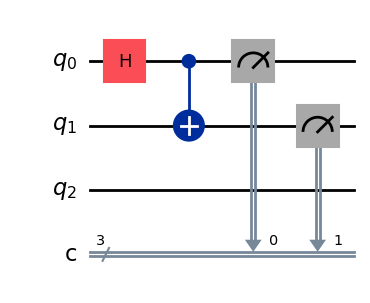

In [5]:
# QASM3 문자열에서 가져오기 예제
qasm_code = """
OPENQASM 3.0;
include "stdgates.inc";

qubit[3] q;
bit[3] c;

h q[0];
cx q[0], q[1];

c[0] = measure q[0];
c[1] = measure q[1];
"""

# 문자열에서 가져오기
circuit = loads(qasm_code)

circuit.draw('mpl')

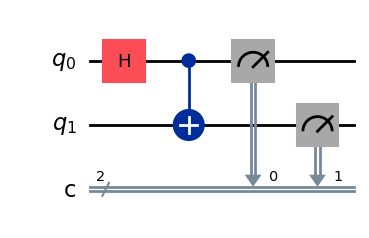

In [6]:
# 파일에서 가져오기 예제
circuit = load("sample_qasm.txt")
circuit.draw('mpl')

#### `QASM3ImporterError`

`Importer`는 지원되지 않는 기능을 만나면 `QASM3ImporterError`를 발생시킵니다.

In [7]:
# 잘못된 QASM3 코드
invalid_qasm = """
OPENQASM 3.0;
include "stdgates.inc";
qubit q;  
rh q; // 알 수 없는 게이트
"""

try:
    circuit = loads(invalid_qasm)
except QASM3ImporterError as e:
    print(f"가져오기 실패: {e}")

Import failed: "5,0: gate 'rh' is not defined."


#### 실험적 가져오기 인터페이스

훨씬 빠른 실험적 Rust 기반 Importer입니다.

##### 가져오기 메서드

* **`load_experimental()`**: 파일에서 회로 가져오기
* **`loads_experimental()`**: 문자열에서 회로 가져오기

c:\QC\venvs\test\.venv\Lib\site-packages\qiskit\qasm3\__init__.py:442: ExperimentalWarning: This is an experimental native version of the OpenQASM 3 importer. Beware that its interface might change, and it might be missing features.
  warnings.warn(


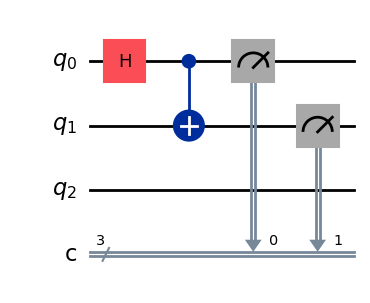

In [8]:
# QASM3 문자열에서 가져오기 예제
qasm_code = """
OPENQASM 3.0;
include "stdgates.inc";

qubit[3] q;
bit[3] c;

h q[0];
cx q[0], q[1];

c[0] = measure q[0];
c[1] = measure q[1];
"""

# 문자열에서 가져오기
circuit = loads_experimental(qasm_code)

circuit.draw('mpl')

---

# 과제 8.3 Qiskit SDK에서의 QASM3

## 목표: OpenQASM의 다양한 버전과 Qiskit 간 상호 운용하기

### QASM3 파일을 Qiskit으로 가져오기


Qiskit은 문자열의 경우 `loads()` 함수를, 파일의 경우 `load()` 함수를 사용하여 OpenQASM 3.0 프로그램을 가져올 수 있습니다.

Qiskit으로의 가져오기는 다음 기능을 지원합니다:

- 기본 양자 게이트 및 회로
- 고전적 제어 흐름 (if/while)
- 사용자 정의 게이트 정의
- 매개변수화된 회로
- 측정 및 리셋 연산

지원 기능에 대한 자세한 내용은 https://quantum.cloud.ibm.com/docs/en/guides/qasm-feature-table 을 참조하세요.

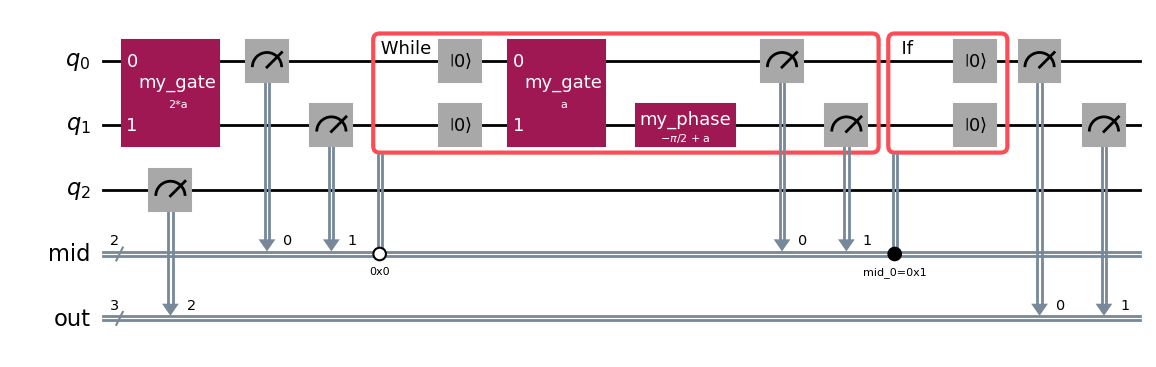

In [9]:
# 복잡한 OpenQASM 3.0 프로그램을 Qiskit으로 가져오기 예제
program = """
    OPENQASM 3.0;
    include "stdgates.inc";
 
    input float[64] a;
    qubit[3] q;
    bit[2] mid;
    bit[3] out;
 
    let aliased = q[0:1];
 
    gate my_gate(a) c, t {
      gphase(a / 2);
      ry(a) c;
      cx c, t;
    }
    gate my_phase(a) c {
      ctrl @ inv @ gphase(a) c;
    }
 
    my_gate(a * 2) aliased[0], q[{1, 2}][0];
    measure q[0] -> mid[0];
    measure q[1] -> mid[1];
 
    while (mid == "00") {
      reset q[0];
      reset q[1];
      my_gate(a) q[0], q[1];
      my_phase(a - pi/2) q[1];
      mid[0] = measure q[0];
      mid[1] = measure q[1];
    }
 
    if (mid[0]) {
      let inner_alias = q[{0, 1}];
      reset inner_alias;
    }
 
    out = measure q;
"""
circuit = loads(program)
circuit.draw("mpl")

### QASM3으로 내보내기


Qiskit은 문자열의 경우 `dumps()`를, 파일의 경우 `dump()`를 사용하여 회로를 OpenQASM 3.0 형식으로 내보낼 수 있습니다.

QASM3으로의 내보내기는 다음 기능을 지원합니다:

- Qiskit 회로를 표준 QASM3 형식으로 변환
- 매개변수화된 회로 지원
- 사용자 정의 게이트 분해 포함 가능
- IBM Quantum Runtime API와 호환

In [10]:
# Qiskit QuantumCircuit를 OpenQASM 3.0 형식의 문자열로 내보내기
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()
 
dumps(qc)

'OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[2] meas;\nqubit[2] q;\nh q[0];\ncx q[0], q[1];\nbarrier q[0], q[1];\nmeas[0] = measure q[0];\nmeas[1] = measure q[1];\n'

In [11]:
# Qiskit QuantumCircuit를 OpenQASM 3.0 형식의 파일로 내보내기
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()
 
with open("sample_qasm.txt", "w") as f:
    dump(qc, f)

---
## 요약
---

이 노트북에서 다룬 내용:

## QASM과 QISKIT 간 상호 변환:

1. **Qiskit에서 QASM으로 내보내기**는 파일 또는 문자열로 할 수 있으며, `Exporter` 클래스를 사용하여 커스터마이징할 수 있습니다.
2. **QASM에서 Qiskit으로 가져오기**는 파일 또는 문자열에서 할 수 있습니다.
3. **실험적 Importer**는 훨씬 빠른 Rust 기반 클래스를 사용합니다.
4. **QASM과 Qiskit 간 가져오기/내보내기**는 특정 기능을 지원합니다.


---

## 연습 문제

**1) Exporter 클래스를 사용하여 QASM3 내보내기를 커스터마이징할 때, 하드웨어 호환성을 위해 내보내는 게이트를 특정 세트로 제한하는 매개변수는 무엇입니까?**

A) allow_aliasing

B) basis_gates

C) includes

D) disable_constants


***정답:***
<Details>
B) basis_gates 매개변수는 특정 대상 하드웨어에서 사용할 게이트 세트를 제한합니다
<br/>
</Details>

---

**2) 다음 코드를 실행하면 무엇이 출력됩니까?**

```
from qiskit.qasm3 import loads

qasm_string = """

OPENQASM 3.0;
include "stdgates.inc";

qubit[3] q;
bit[3] c;

h q[0];
cx q[0], q[1];

c[0] = measure q0;
c[1] = measure q1;
"""

try:
    circuit = loads(qasm_string)
    print("회로가 성공적으로 로드되었습니다")
except Exception as e:
    print(f"오류: {type(e).__name__}")
```

A) 회로가 성공적으로 로드되었습니다

B) 오류: QASM3ExporterError

C) 오류: QASM3ImportError

D) 오류: QASM3ImporterError


***정답:***
<Details>
D) 존재하지 않는 큐비트 q0과 q1에 대해 측정을 수행하므로 QASM3ImporterError가 발생합니다
<br/>
</Details>

---

**3) 아래 코드에 대해 올바른 설명은 무엇입니까?**

```
from qiskit.qasm3 import loads

qasm = """
OPENQASM 3.0;
include "stdgates.inc";

qubit q;
bit c;

h q;

c = measure q;

if (c) {
  x q;
}
"""
qc = loads(qasm)
print(qc)
```

A) 회로가 QuantumCircuit로 가져와져서 출력됩니다

B) 고전적 if문은 지원되지 않으므로 무시됩니다

C) 가져오기에 실패하고 QASM3ImporterError가 발생합니다

D) 회로가 가져와져서 실행됩니다

***정답:***
<Details>
A) 고전적 if, 기본 게이트 및 측정이 지원되므로 회로가 가져와져서 출력됩니다.
<br/>
</Details>

---

**4) dump()와 dumps()의 주요 차이점은 무엇입니까?**

A) dump()는 문자열을 반환하고, dumps()는 파일 객체에 저장합니다

B) dump()는 QASM2용이고, dumps()는 QASM3용입니다

C) dump()는 파일 객체에 저장하고, dumps()는 문자열을 반환합니다

D) dumps()는 특수 기능을 지원하고, dump()는 지원하지 않습니다

***정답:***
<Details>

C) dump()는 회로를 QASM 스크립트로 변환하여 디스크에 파일로 저장하고, dumps()는 회로를 QASM 스크립트로 변환하여 문자열로 반환합니다
<br/>
</Details>

---